# COMP9517 Lab 4 - Image Segmentation with Thresholding and Morphology

This notebook implements a single segmentation pipeline for all lab images.

Pipeline:
1. Read image
2. Convert to grayscale
3. Apply Otsu thresholding
4. Apply morphological opening and closing
5. Remove objects touching the image border
6. Remove small connected components
7. Count the remaining objects

In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path(r"C:\Users\ROG\Desktop\UNSW\COMP9517\lab4\COMP9517_26T1_Lab4_Images")
print("Image folder exists:", BASE_DIR.exists())
print("Folder path:", BASE_DIR)

Image folder exists: True
Folder path: C:\Users\ROG\Desktop\UNSW\COMP9517\lab4\COMP9517_26T1_Lab4_Images


In [3]:
image_files = sorted([
    p for p in BASE_DIR.iterdir()
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
])

print("Found images:")

for p in image_files:
    print(" -", p.name)

Found images:
 - Fruits.jpg
 - Monsters.jpg
 - Strawberries.jpg


In [4]:
def show_images(images, titles=None, cmap='gray', figsize=(18, 8)):
    n = len(images)
    plt.figure(figsize=figsize)
    
    for i, img in enumerate(images, 1):
        plt.subplot(1, n, i)
        
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        
        plt.axis('off')
        if titles is not None:
            plt.title(titles[i-1])
    
    plt.tight_layout()
    plt.show()

In [5]:
def otsu_foreground_white(gray):
    """
    Apply Otsu thresholding and automatically choose the version
    where foreground objects are white (255) and background is black (0).
    """
    # ordinary Otsu
    _, t1 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # reversed
    t2 = cv2.bitwise_not(t1)

    def border_white_ratio(binary):
        border = np.concatenate([
            binary[0, :], binary[-1, :], binary[:, 0], binary[:, -1]
        ])
        return np.mean(border == 255)

    # Make the boundaries as black as possible, because the background usually touches the image boundaries.
    
    return t1 if border_white_ratio(t1) < border_white_ratio(t2) else t2

In [6]:
def morphological_reconstruction(marker, mask, kernel=None):
    """
    Binary morphological reconstruction by dilation.
    marker and mask should be uint8 images with values 0 or 255.
    """
    if kernel is None:
        kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))

    marker = marker.copy().astype(np.uint8)
    mask = mask.copy().astype(np.uint8)

    while True:
        prev = marker.copy()
        marker = cv2.dilate(marker, kernel)
        marker = cv2.bitwise_and(marker, mask)
        
        if np.array_equal(marker, prev):
            break

    return marker

In [7]:
def clear_border_by_reconstruction(binary):
    """
    Remove foreground objects touching the image border.
    Input binary image should have foreground = 255, background = 0.
    """
    marker = np.zeros_like(binary, dtype=np.uint8)

    # Only extract the foreground at the boundary as the marker
    marker[0, :] = binary[0, :]
    marker[-1, :] = binary[-1, :]
    marker[:, 0] = binary[:, 0]
    marker[:, -1] = binary[:, -1]

    border_objects = morphological_reconstruction(marker, binary)
    cleared = cv2.subtract(binary, border_objects)

    return cleared

In [8]:
def remove_small_components(binary, min_area=100):
    """
    Keep only connected components whose area >= min_area.
    """
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    cleaned = np.zeros_like(binary, dtype=np.uint8)

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == label] = 255

    return cleaned

In [9]:
def segment_and_count(
    image_path,
    open_ksize=3,
    close_ksize=7,
    min_area=300,
    show_steps=True
):
    """
    Single segmentation pipeline for all images.
    
    Parameters
    ----------
    image_path : str or Path
        Path to input image
    open_ksize : int
        Kernel size for opening (should be odd)
    close_ksize : int
        Kernel size for closing (should be odd)
    min_area : int
        Minimum connected component area to keep
    show_steps : bool
        Whether to display intermediate results
    """
    
    image = cv2.imread(str(image_path))
    
    if image is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Step 1: Otsu thresholding
    binary = otsu_foreground_white(gray)

    # Step 2: Morphological opening and closing
    open_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_ksize, open_ksize))
    close_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_ksize, close_ksize))

    opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, open_kernel)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, close_kernel)

    # Step 3: Remove border-touching objects
    no_border = clear_border_by_reconstruction(closed)

    # Step 4: Remove small objects
    final_mask = remove_small_components(no_border, min_area=min_area)

    # Step 5: Count connected components
    n_labels, _, _, _ = cv2.connectedComponentsWithStats(final_mask, connectivity=8)
    count = n_labels - 1 

    if show_steps:
        show_images(
            [image, gray, binary, opened, closed, no_border, final_mask],
            [
                "Original",
                "Gray",
                "Otsu",
                "Opening",
                "Closing",
                "Border Removed",
                f"Final (n={count})"
            ],
            figsize=(22, 8)
        )

    return final_mask, count

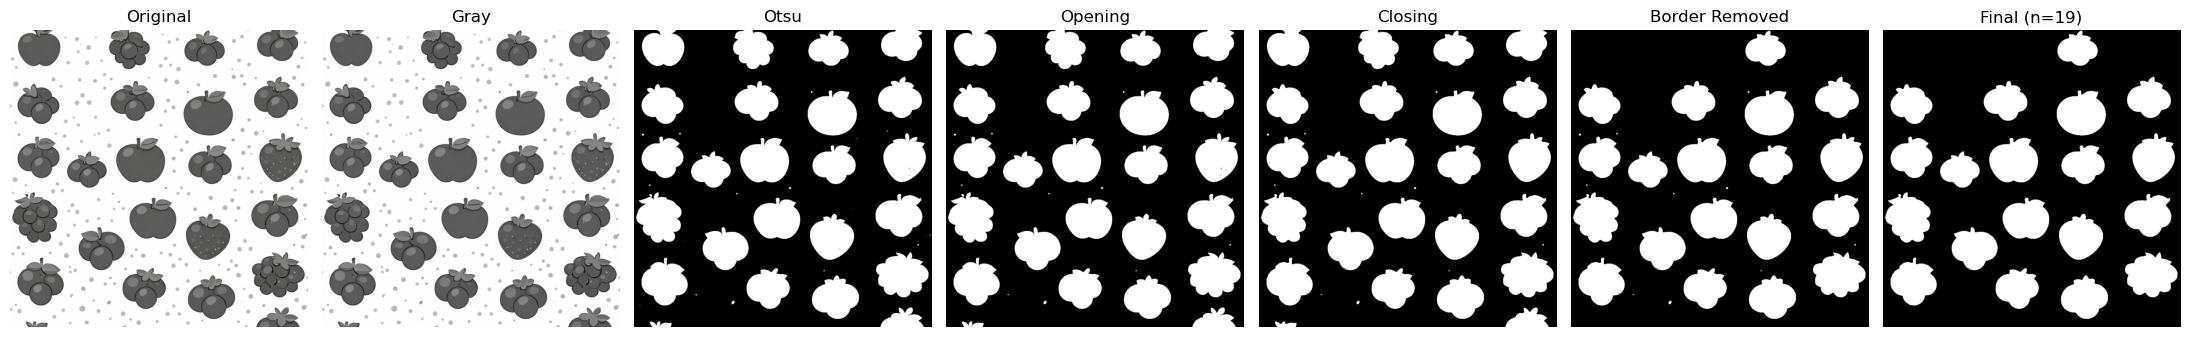

Final object count = 19


In [10]:
test_image = BASE_DIR / "fruits.jpg"  
mask, count = segment_and_count(
    test_image,
    open_ksize=3,
    close_ksize=7,
    min_area=300,
    show_steps=True
)

print("Final object count =", count)

In [11]:
def run_all_images(param_dict):
    results = {}
    
    for name, params in param_dict.items():
        image_path = BASE_DIR / name
        print("=" * 60)
        print("Processing:", name)
        print("Parameters:", params)
        
        _, count = segment_and_count(
            image_path,
            open_ksize=params["open_ksize"],
            close_ksize=params["close_ksize"],
            min_area=params["min_area"],
            show_steps=True
        )
        
        print("Detected objects =", count)
        results[name] = count
    
    return results

In [12]:
params = {
    "fruits.jpg": {
        "open_ksize": 3,
        "close_ksize": 7,
        "min_area": 300
    },
    "strawberries.jpg": {
        "open_ksize": 3,
        "close_ksize": 9,
        "min_area": 500
    },
    "monsters.jpg": {
        "open_ksize": 3,
        "close_ksize": 7,
        "min_area": 350
    }
}

Processing: fruits.jpg
Parameters: {'open_ksize': 3, 'close_ksize': 7, 'min_area': 300}


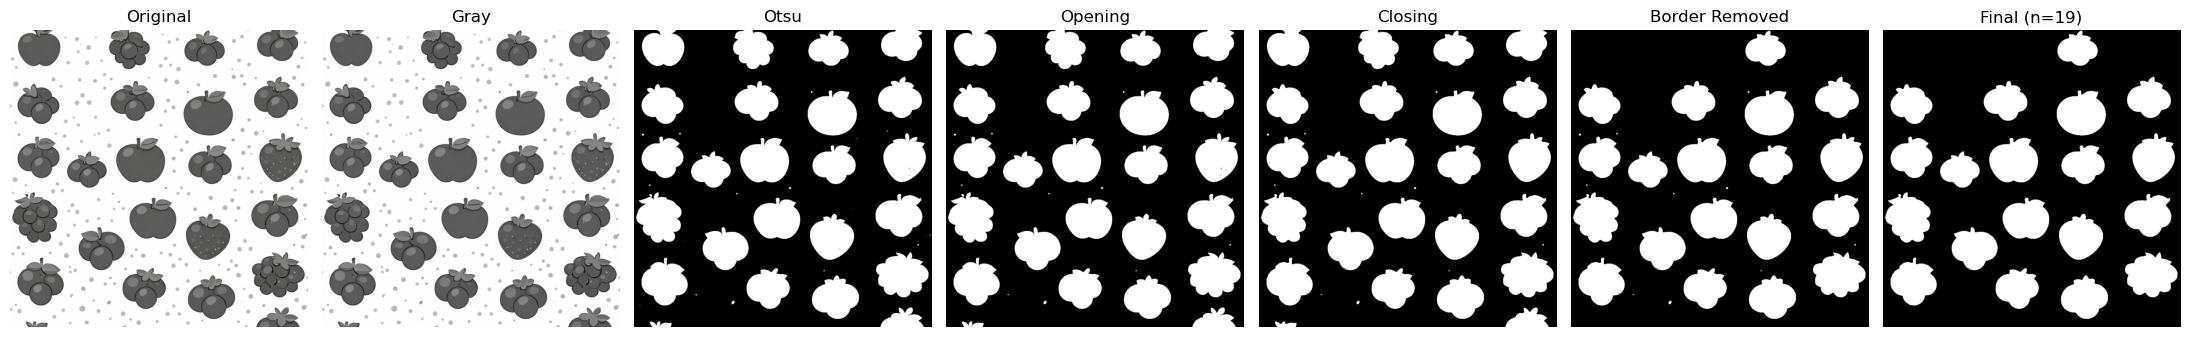

Detected objects = 19
Processing: strawberries.jpg
Parameters: {'open_ksize': 3, 'close_ksize': 9, 'min_area': 500}


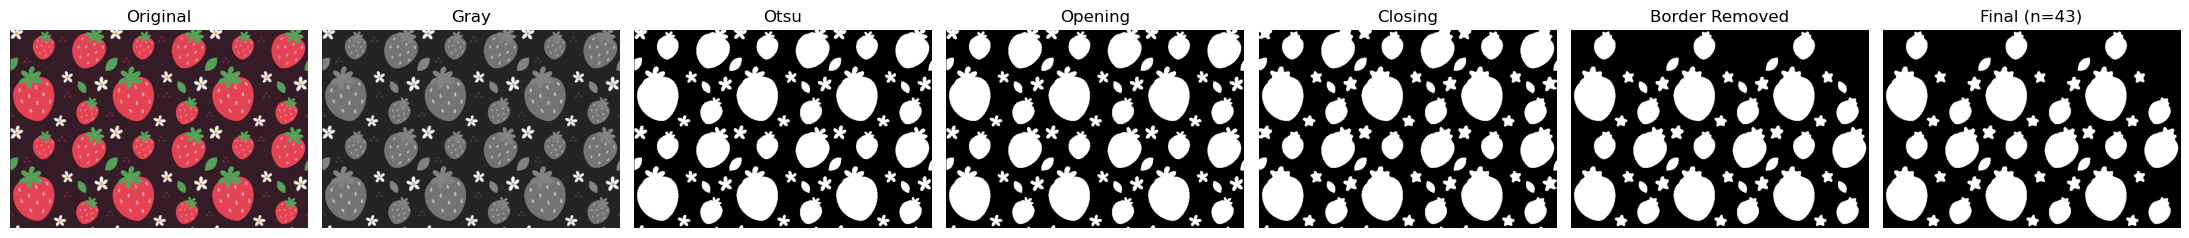

Detected objects = 43
Processing: monsters.jpg
Parameters: {'open_ksize': 3, 'close_ksize': 7, 'min_area': 350}


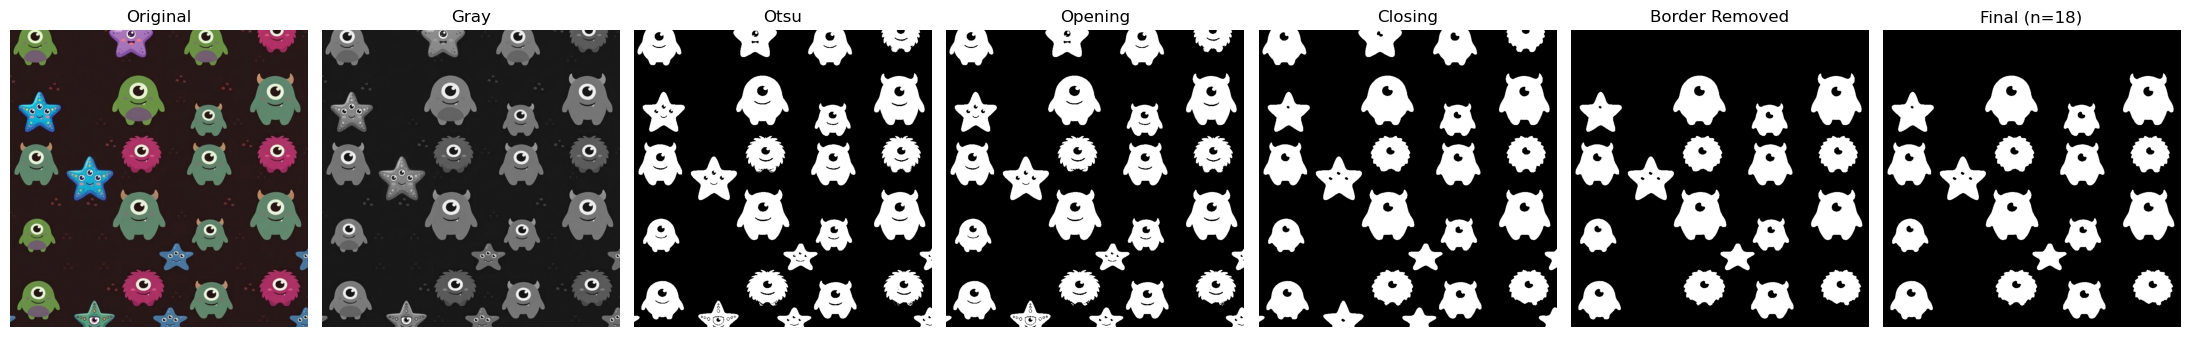

Detected objects = 18

Final summary:
fruits.jpg: n = 19
strawberries.jpg: n = 43
monsters.jpg: n = 18


In [13]:
results = run_all_images(params)
print("\nFinal summary:")
for k, v in results.items():
    print(f"{k}: n = {v}")

In [14]:
output_dir = BASE_DIR / "output_masks"
output_dir.mkdir(exist_ok=True)

for name, p in params.items():
    image_path = BASE_DIR / name
    final_mask, count = segment_and_count(
        image_path,
        open_ksize=p["open_ksize"],
        close_ksize=p["close_ksize"],
        min_area=p["min_area"],
        show_steps=False
    )
    
    save_path = output_dir / f"{Path(name).stem}_mask_n{count}.png"
    cv2.imwrite(str(save_path), final_mask)
    print("Saved:", save_path)

Saved: C:\Users\ROG\Desktop\UNSW\COMP9517\lab4\COMP9517_26T1_Lab4_Images\output_masks\fruits_mask_n19.png
Saved: C:\Users\ROG\Desktop\UNSW\COMP9517\lab4\COMP9517_26T1_Lab4_Images\output_masks\strawberries_mask_n43.png
Saved: C:\Users\ROG\Desktop\UNSW\COMP9517\lab4\COMP9517_26T1_Lab4_Images\output_masks\monsters_mask_n18.png


## Conclusion

A single segmentation pipeline was used for all images:
- grayscale conversion
- Otsu thresholding
- opening
- closing
- border-object removal by reconstruction
- removal of small connected components
- connected component counting

The threshold was selected automatically by Otsu's method.
Only parameter values such as morphological kernel sizes and minimum component area were adjusted for different images.